In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = "/work/gbadarac/MonoJet_NPLM/MonoJet_NPLM_analysis"

OUT_DIR = os.path.join(REPO_ROOT,
    "Generate_Ensemble_Data_Hit_or_Miss_MC",
    "Sparker_kernels",
    "saved_generated_kernel_ensemble_data"
)

# Training dataset used to train the ensemble and fit the WiFi weights.
# This is the correct reference: the ensemble approximates THIS distribution,
# so hit-or-miss samples should look like THIS data, not fresh analytic draws.
TARGET_DATA = os.path.join(REPO_ROOT,
    "Train_Ensembles", "Generate_Data", "saved_generated_target_data",
    "2_dim", "100k_2d_gaussian_heavy_tail_target_set.npy"
)

truth = np.load(TARGET_DATA)
print("Target dataset shape:", truth.shape)   # expect (100000, 2)

bins_x1 = np.linspace(-1.5, 0.5, 50)
bins_x2 = np.linspace(0.5, 4.5, 50)

Target dataset shape: (100000, 2)


## 1. Check a single seed file

In [3]:
# Adjust seed to whichever file you want to inspect
seed = 0

samples = np.load(os.path.join(OUT_DIR, "seed%i.npy" % seed))
print("Shape:", samples.shape)          # expect (5000, 2)
print("x1 range: [%.3f, %.3f]" % (samples[:, 0].min(), samples[:, 0].max()))
print("x2 range: [%.3f, %.3f]" % (samples[:, 1].min(), samples[:, 1].max()))

Shape: (5000, 2)
x1 range: [-1.113, 0.235]
x2 range: [0.782, 3.799]


## 2. 2D scatter plot

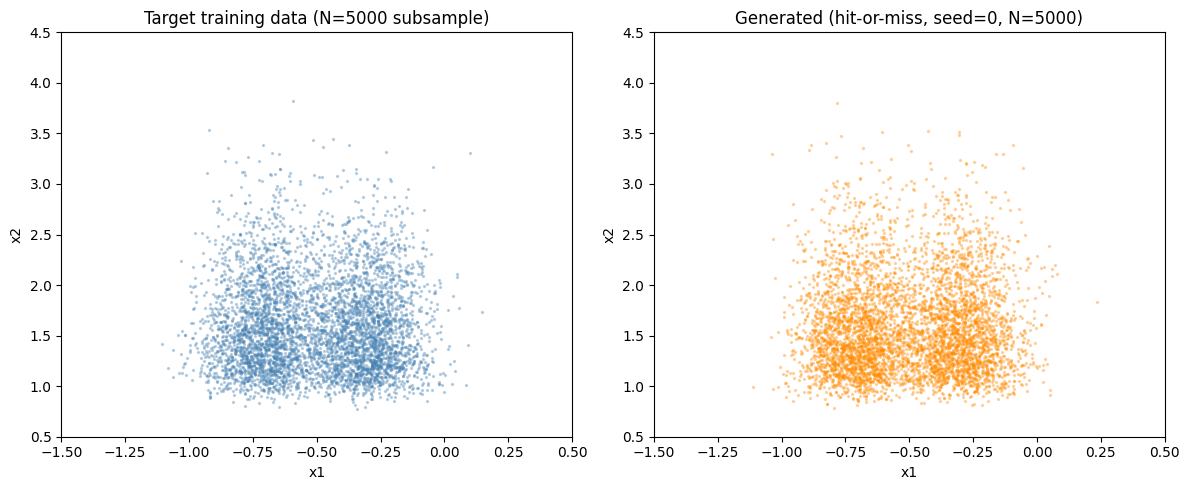

In [4]:
# Subsample 5000 from the 100k truth for a fair visual comparison
rng = np.random.default_rng(42)
truth_sub = truth[rng.choice(len(truth), size=5000, replace=False)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(truth_sub[:, 0], truth_sub[:, 1], s=2, alpha=0.3, color="steelblue")
axes[0].set_title("Target training data (N=5000 subsample)")
axes[0].set_xlabel("x1"); axes[0].set_ylabel("x2")
axes[0].set_xlim(-1.5, 0.5); axes[0].set_ylim(0.5, 4.5)

axes[1].scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.3, color="darkorange")
axes[1].set_title("Generated (hit-or-miss, seed=%i, N=%i)" % (seed, len(samples)))
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2")
axes[1].set_xlim(-1.5, 0.5); axes[1].set_ylim(0.5, 4.5)

plt.tight_layout()
plt.show()

## 3. 1D marginal histograms vs. training data

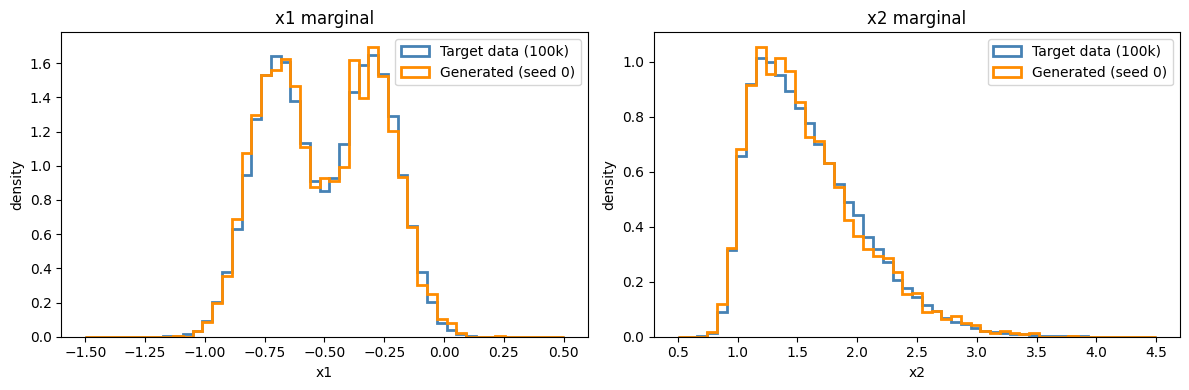

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(truth[:, 0], bins=bins_x1, density=True,
             histtype="step", color="steelblue", linewidth=2, label="Target data (100k)")
axes[0].hist(samples[:, 0], bins=bins_x1, density=True,
             histtype="step", color="darkorange", linewidth=2, label="Generated (seed %i)" % seed)
axes[0].set_xlabel("x1"); axes[0].set_ylabel("density")
axes[0].set_title("x1 marginal")
axes[0].legend()

axes[1].hist(truth[:, 1], bins=bins_x2, density=True,
             histtype="step", color="steelblue", linewidth=2, label="Target data (100k)")
axes[1].hist(samples[:, 1], bins=bins_x2, density=True,
             histtype="step", color="darkorange", linewidth=2, label="Generated (seed %i)" % seed)
axes[1].set_xlabel("x2"); axes[1].set_ylabel("density")
axes[1].set_title("x2 marginal")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Check all available seed files

In [6]:
seed_files = sorted([f for f in os.listdir(OUT_DIR) if f.endswith(".npy")])
print("Files found: %i" % len(seed_files))

n_events = []
for f in seed_files:
    arr = np.load(os.path.join(OUT_DIR, f))
    n_events.append(arr.shape[0])

n_events = np.array(n_events)
print("Events per file: min=%i  max=%i  mean=%.1f" % (n_events.min(), n_events.max(), n_events.mean()))
print("Total events: %i" % n_events.sum())

wrong = [(f, n) for f, n in zip(seed_files, n_events) if n != 5000]
if wrong:
    print("WARNING: files with unexpected event count:")
    for f, n in wrong:
        print("  %s: %i" % (f, n))
else:
    print("All files have exactly 5000 events. \u2713")

Files found: 181
Events per file: min=5000  max=5000  mean=5000.0
Total events: 905000
All files have exactly 5000 events. ✓


## 5. Overlay of all seeds vs. training data (x1 and x2 marginals)

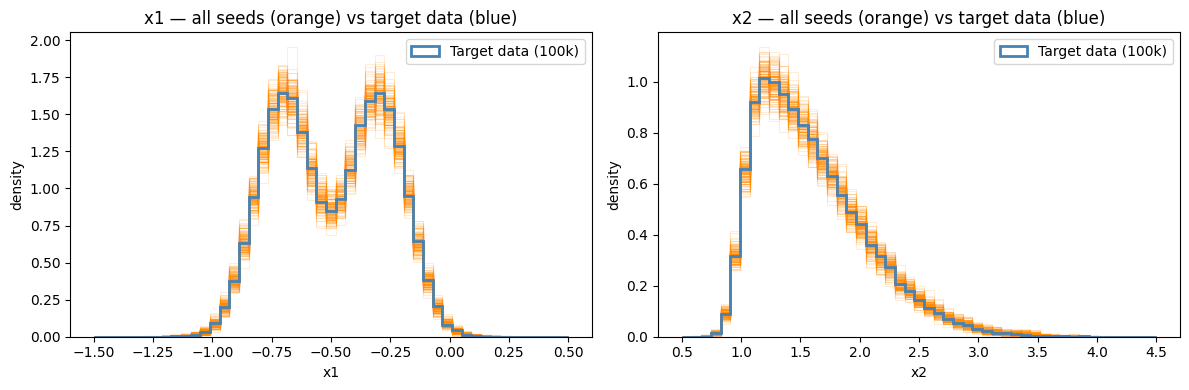

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for f in seed_files:
    arr = np.load(os.path.join(OUT_DIR, f))
    axes[0].hist(arr[:, 0], bins=bins_x1, density=True,
                 histtype="step", color="darkorange", alpha=0.15, linewidth=0.8)
    axes[1].hist(arr[:, 1], bins=bins_x2, density=True,
                 histtype="step", color="darkorange", alpha=0.15, linewidth=0.8)

axes[0].hist(truth[:, 0], bins=bins_x1, density=True,
             histtype="step", color="steelblue", linewidth=2, label="Target data (100k)")
axes[1].hist(truth[:, 1], bins=bins_x2, density=True,
             histtype="step", color="steelblue", linewidth=2, label="Target data (100k)")

axes[0].set_xlabel("x1"); axes[0].set_title("x1 — all seeds (orange) vs target data (blue)")
axes[1].set_xlabel("x2"); axes[1].set_title("x2 — all seeds (orange) vs target data (blue)")
for ax in axes:
    ax.set_ylabel("density")
    ax.legend()

plt.tight_layout()
plt.show()